In [1]:
import os
import random
import subprocess
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2
import tifffile as tiff

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                      concatenate, Conv2DTranspose,
                                      BatchNormalization, Activation)
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

2026-03-04 15:32:32.575695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772638352.754251      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772638352.801893      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772638353.213533      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772638353.213563      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772638353.213566      24 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = '/kaggle/input/datasets/saharamrr/satalitedataset/data'
dataset_dir = os.listdir(dataset_path)
print(f'the data contains {dataset_dir}')

the data contains ['labels', 'images']


# **STEP 1: Data Alignment (Pairing Images with Labels)**

## What is Data Alignment?
- **Satellite Dataset Structure**: TIF files (images) and PNG files (ground truth labels)
- **Goal**: Ensure each satellite image has a matching label
- **Action**: Find common filenames between folders
- **Why**: Missing pairs cause training errors

In [3]:
image_dir = os.path.join(dataset_path, 'images')
mask_dir = os.path.join(dataset_path, 'labels')

image_paths = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))

images = [tiff.imread(p) for p in image_paths]
masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in mask_paths]

print("Images found:", len(image_paths))
print("Labels found:", len(mask_paths))

if len(images) > 0:
    print(f"Sample Image Shape: {images[0].shape}")
    print(f"Sample Mask Shape: {masks[0].shape}")

Images found: 306
Labels found: 456
Sample Image Shape: (128, 128, 12)
Sample Mask Shape: (128, 128)


In [4]:
image_names = set([os.path.splitext(os.path.basename(f))[0] for f in image_paths])
label_names = set([os.path.splitext(os.path.basename(f))[0] for f in mask_paths])

print("Images without labels:", len(image_names - label_names))
print("Labels without images:", len(label_names - image_names))

Images without labels: 0
Labels without images: 150


In [5]:
common_names = sorted(list(image_names & label_names))
print("Total valid pairs:", len(common_names))

Total valid pairs: 306


In [6]:
clean_image_paths = [os.path.join(image_dir, name + ".tif") for name in common_names]
clean_label_paths = [os.path.join(mask_dir, name + ".png") for name in common_names]

print("Clean images list size:", len(clean_image_paths))
print("Clean labels list size:", len(clean_label_paths))

Clean images list size: 306
Clean labels list size: 306


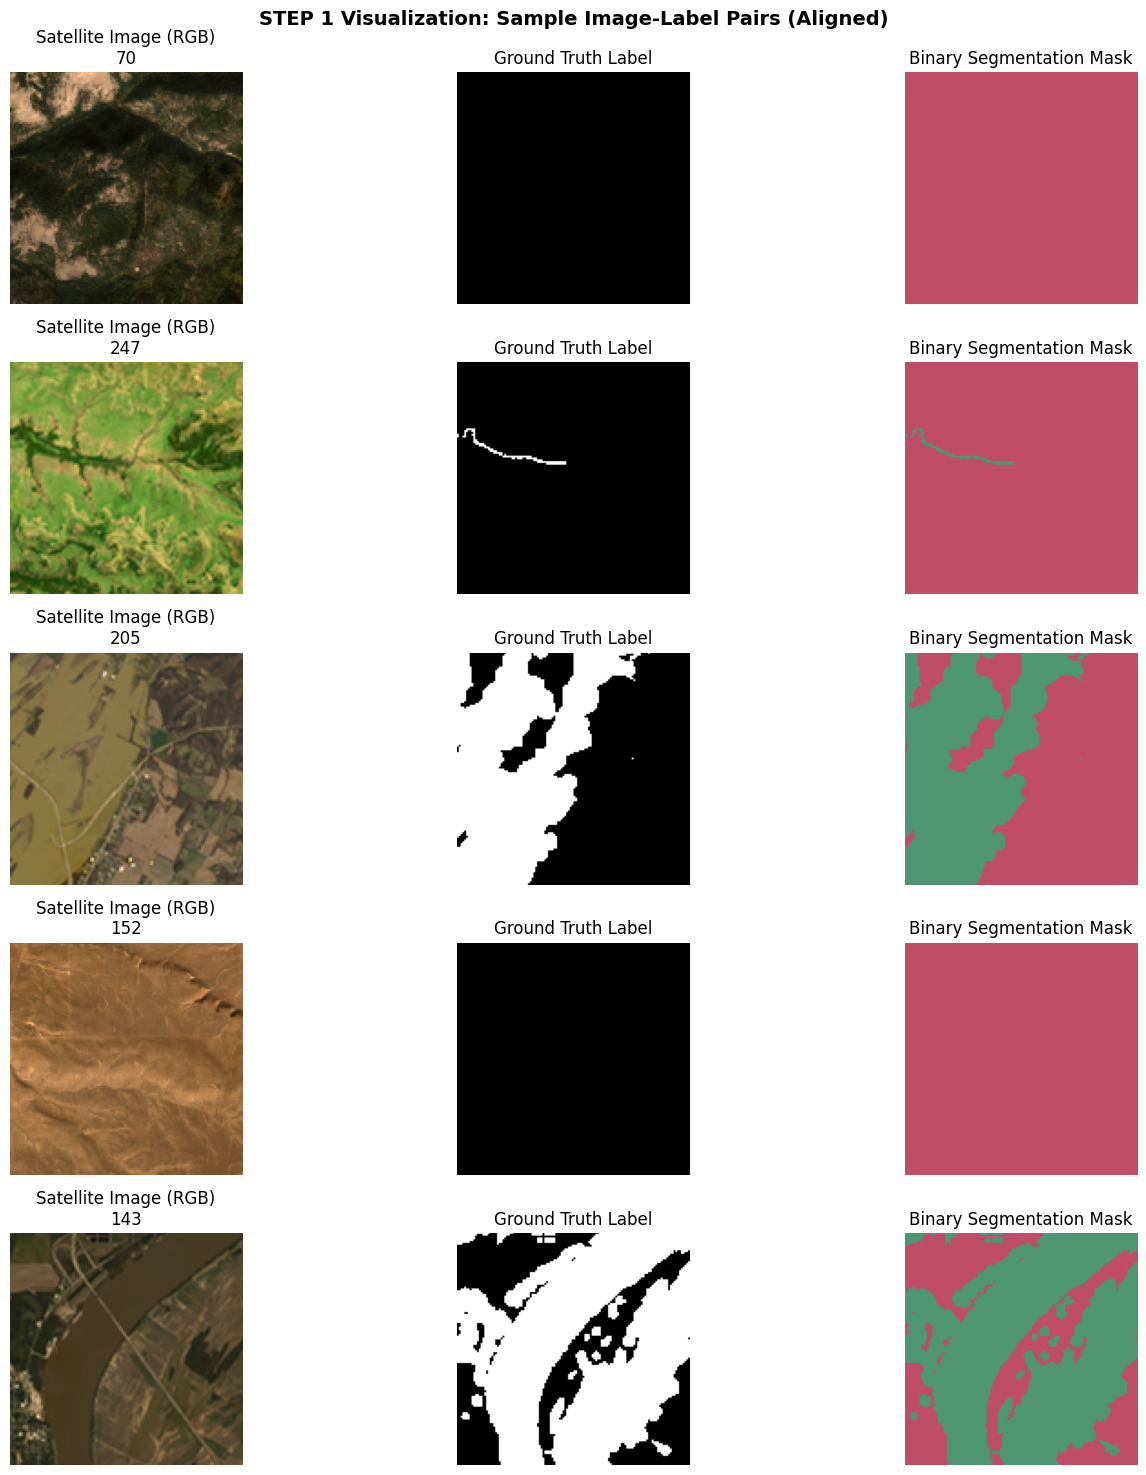

In [7]:
sample_indices = random.sample(range(len(common_names)), min(5, len(common_names)))

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 3*len(sample_indices)))
fig.suptitle('STEP 1 Visualization: Sample Image-Label Pairs (Aligned)', fontsize=14, fontweight='bold')

for row, idx in enumerate(sample_indices):
    name = common_names[idx]
    img_path = os.path.join(image_dir, name + ".tif")
    label_path = os.path.join(mask_dir, name + ".png")
    
    img = tiff.imread(img_path)
    rgb_img = np.stack([img[:,:,3], img[:,:,2], img[:,:,1]], axis=-1)
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
    
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    
    axes[row, 0].imshow(rgb_img)
    axes[row, 0].set_title(f'Satellite Image (RGB)\n{name}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(label, cmap='gray')
    axes[row, 1].set_title(f'Ground Truth Label')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(label > 0, cmap='RdYlGn', alpha=0.7)
    axes[row, 2].set_title(f'Binary Segmentation Mask')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('step1_data_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

# **STEP 2: Normalization**

- **Raw TIF values**: Often 0 to 10,000+ (different range for each band)
- **After normalization**: All bands scaled to [0, 1]
- **Method**: Min-Max scaling: (x - min) / (max - min)

In [8]:
images_all = [tiff.imread(p) for p in clean_image_paths]
masks_all = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in clean_label_paths]

print(f"Loaded {len(images_all)} images and {len(masks_all)} masks.")

Loaded 306 images and 306 masks.


In [9]:
band_names = ['Coastal Aerosol','Blue','Green','Red','NIR','SWIR1','SWIR2',
              'QA Band','Merit DEM','Copernicus DEM','ESA WorldCover','Water Prob']
num_bands = 12

global_min = np.full(num_bands, np.inf)
global_max = np.full(num_bands, -np.inf)

for idx, img in enumerate(images_all):
    img_data = img.astype(np.float32)
    for b in range(num_bands):
        band_data = img_data[:, :, b]
        if band_data.min() < global_min[b]:
            global_min[b] = band_data.min()
        if band_data.max() > global_max[b]:
            global_max[b] = band_data.max()

band_stats = pd.DataFrame({
    'Band': [f'{i+1}: {name}' for i, name in enumerate(band_names)],
    'Min': global_min,
    'Max': global_max,
    'Range': global_max - global_min
})

print("BAND-WISE MIN/MAX STATISTICS (Across All Images)")
print(band_stats.to_string(index=False))

band_stats_dict = {
    'min': global_min,
    'max': global_max,
    'names': band_names
}

BAND-WISE MIN/MAX STATISTICS (Across All Images)
              Band     Min     Max   Range
1: Coastal Aerosol -1393.0  6568.0  7961.0
           2: Blue -1169.0  9659.0 10828.0
          3: Green  -722.0 11368.0 12090.0
            4: Red  -684.0 12041.0 12725.0
            5: NIR  -412.0 15841.0 16253.0
          6: SWIR1  -335.0 15252.0 15587.0
          7: SWIR2  -258.0 14647.0 14905.0
        8: QA Band    64.0   255.0   191.0
      9: Merit DEM -9999.0  4245.0 14244.0
10: Copernicus DEM     8.0  4287.0  4279.0
11: ESA WorldCover    10.0   100.0    90.0
    12: Water Prob     0.0   111.0   111.0


In [10]:
# Normalize each image band using global min/max
images_norm = np.zeros((len(images_all), 128, 128, num_bands), dtype=np.float32)

for i, img in enumerate(images_all):
    img_data = img.astype(np.float32)
    for b in range(num_bands):
        band_min = band_stats_dict['min'][b]
        band_max = band_stats_dict['max'][b]
        denom = band_max - band_min
        if denom > 0:
            images_norm[i, :, :, b] = (img_data[:, :, b] - band_min) / denom
        else:
            images_norm[i, :, :, b] = 0.0

# Also convert masks to numpy array
# إعادة تحميل الـ masks بدون قسمة على 255
masks_all = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in clean_label_paths]
masks_all_arr = np.array(masks_all, dtype=np.float32)  # مش /255

# تحقق
print(f"Unique values: {np.unique(masks_all_arr)}")  # المفروض [0. 1.]
print(f"Water ratio: {masks_all_arr.mean():.4f}")
print(f"images_norm shape: {images_norm.shape}")
print(f"masks_all_arr shape: {masks_all_arr.shape}")
print(f"Pixel value range: [{images_norm.min():.3f}, {images_norm.max():.3f}]")

Unique values: [0. 1.]
Water ratio: 0.2598
images_norm shape: (306, 128, 128, 12)
masks_all_arr shape: (306, 128, 128)
Pixel value range: [0.000, 1.000]


In [11]:
def dice_coef(y_true, y_pred, smooth=100):
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [12]:
def build_vgg16_unet(input_shape):
    inputs = Input(input_shape)
    vgg16 = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    s1 = vgg16.get_layer("block1_conv2").output
    s2 = vgg16.get_layer("block2_conv2").output
    s3 = vgg16.get_layer("block3_conv3").output
    s4 = vgg16.get_layer("block4_conv3").output
    bridge = vgg16.get_layer("block5_conv3").output

    def decoder_block(input_tensor, skip_features, num_filters):
        x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input_tensor)
        x = concatenate([x, skip_features])
        x = Conv2D(num_filters, 3, padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)  # ← جديد
        x = Conv2D(num_filters, 3, padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        return x

    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, (1, 1), padding="same", activation="sigmoid")(d4)
    model = Model(inputs, outputs, name="VGG16_UNet")
    return model

In [13]:
print(images_norm.shape)        # expect (306, 128, 128, 12)
print(masks_all_arr.shape)      # expect (306, 128, 128)

(306, 128, 128, 12)
(306, 128, 128)


In [14]:
images_3ch = images_norm[:, :, :, [3, 2, 1]]

all_indices = np.arange(len(images_3ch))
train_indices, temp_indices = train_test_split(all_indices, test_size=0.3, random_state=42)
val_indices, test_indices   = train_test_split(temp_indices, test_size=0.5, random_state=42)

# أعد الـ split
train_data = {'images': images_3ch[train_indices], 'masks': masks_all_arr[train_indices]}
val_data   = {'images': images_3ch[val_indices],   'masks': masks_all_arr[val_indices]}
test_data  = {'images': images_3ch[test_indices],  'masks': masks_all_arr[test_indices]}

train_data['masks'] = np.expand_dims(train_data['masks'], axis=-1)
val_data['masks']   = np.expand_dims(val_data['masks'],   axis=-1)
test_data['masks']  = np.expand_dims(test_data['masks'],  axis=-1)

print(f"Train masks max: {train_data['masks'].max()}")  # المفروض 1.0

Train masks max: 1.0


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation للـ training بس
def augment(image, mask):
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)
    # Random brightness
    image = tf.image.random_brightness(image, 0.1)
    image = tf.clip_by_value(image, 0, 1)
    return image, mask

# حوّل الـ data لـ tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_data['images'], train_data['masks'])
)
train_dataset = (train_dataset
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(200)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_data['images'], val_data['masks'])
).batch(16).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1772638386.050482      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772638386.056666      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
def dice_coef(y_true, y_pred, smooth=100):
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [17]:
model = build_vgg16_unet(input_shape=(128, 128, 3))  # بدون Dropout
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=['binary_accuracy', dice_coef]
)

history = model.fit(
    train_data['images'],
    train_data['masks'],
    validation_data=(val_data['images'], val_data['masks']),
    epochs=50,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max',
                                          patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coef', mode='max',
                                              factor=0.5, patience=5)
    ],
    verbose=1
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1772638397.281455      72 service.cc:152] XLA service 0x7b2834003520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772638397.281491      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772638397.281495      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772638399.114091      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-04 15:33:28.832937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:33:29.135060: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:33:30.763873: E external/local_xl

13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - binary_accuracy: 0.5649 - dice_coef: 0.3433 - loss: 1.3501

2026-03-04 15:34:01.314119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:34:01.535210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:34:03.198014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:34:03.498629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:34:04.502185: E external/local_xla/xla/stream_

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.5670 - dice_coef: 0.3450 - loss: 1.3466   

2026-03-04 15:34:33.217020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:34:33.448737: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


14/14 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - binary_accuracy: 0.5688 - dice_coef: 0.3465 - loss: 1.3436 - val_binary_accuracy: 0.7406 - val_dice_coef: 0.1083 - val_loss: 1.6896 - learning_rate: 1.0000e-04
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step - binary_accuracy: 0.6971 - dice_coef: 0.4384 - loss: 1.1445 - val_binary_accuracy: 0.7406 - val_dice_coef: 0.0564 - val_loss: 1.9866 - learning_rate: 1.0000e-04
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step - binary_accuracy: 0.7514 - dice_coef: 0.5485 - loss: 0.9878 - val_binary_accuracy: 0.7406 - val_dice_coef: 0.0732 - val_loss: 1.8522 - learning_rate: 1.0000e-04
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step - binary_accuracy: 0.8191 - dice_coef: 0.5501 - loss: 0.8969 - val_binary_accuracy: 0.7406 - val_dice_coef: 0.1213 - val_loss: 1.6379 - learning_rate: 1.0000e-04
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - binary_accuracy: 0.8045 - dice_coef: 0.5597 - loss: 0.9216 - val_binary_accuracy: 0.7663 - val_dice_coe

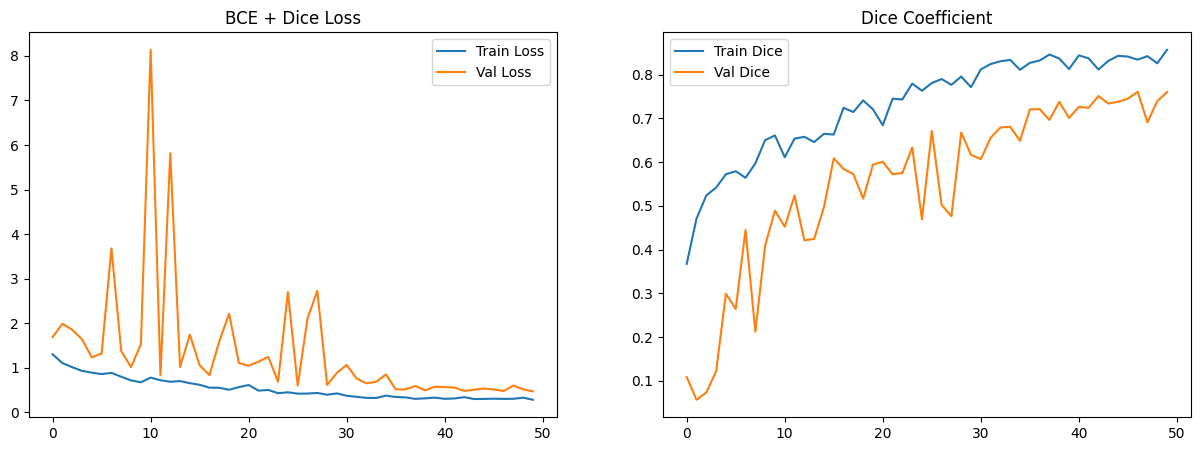

In [18]:
def plot_history(history):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('BCE + Dice Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['dice_coef'], label='Train Dice')
    plt.plot(history.history['val_dice_coef'], label='Val Dice')
    plt.title('Dice Coefficient')
    plt.legend()
    
    plt.show()

plot_history(history)

2026-03-04 15:38:00.975748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 15:38:01.180843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


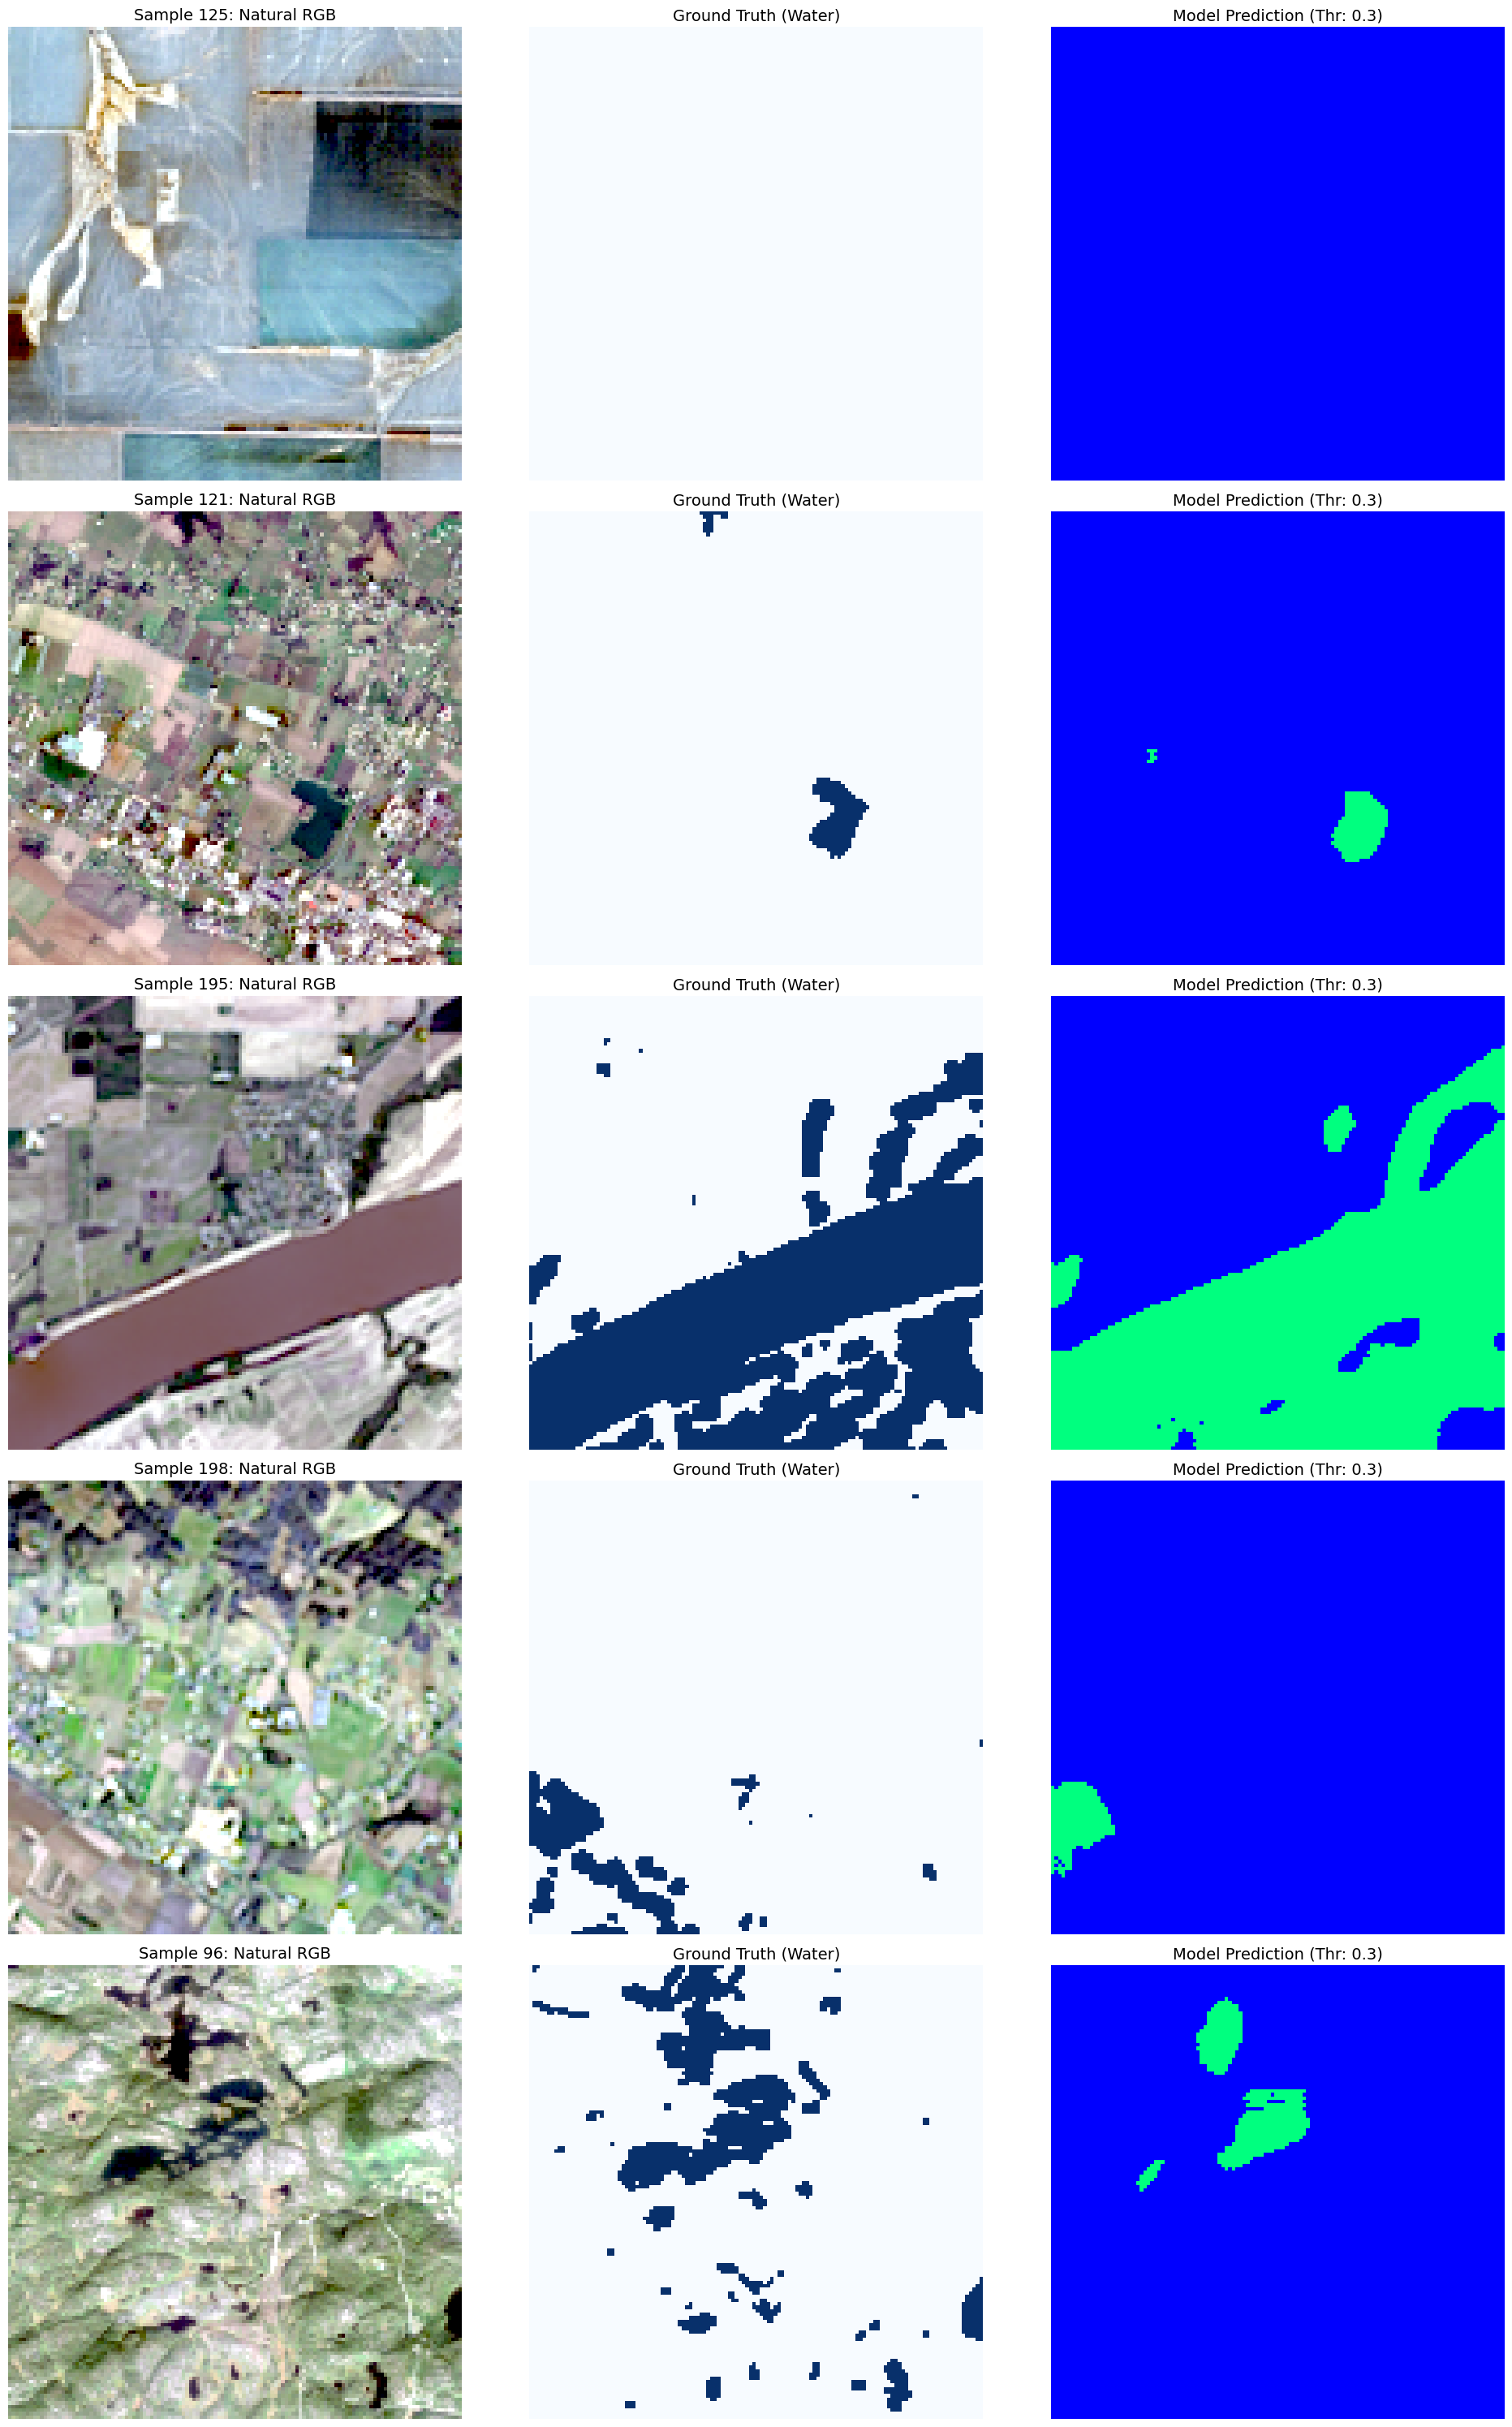

In [19]:
def visualize_five_samples(model, images_array, masks_array, n=5, gamma=0.6, threshold=0.5):
    indices = np.random.choice(len(images_array), n, replace=False)
    plt.figure(figsize=(20, n * 6))
    
    for i, idx in enumerate(indices):
        img_raw = images_array[idx].copy().astype(np.float32)
        mask = masks_array[idx].squeeze()
        
        pred = model.predict(np.expand_dims(images_array[idx], axis=0), verbose=0)
        pred_mask = (pred.squeeze() > threshold).astype(np.float32)
        
        img_fixed = np.zeros_like(img_raw)
        for ch in range(3):
            ch_min, ch_max = np.percentile(img_raw[:,:,ch], (2, 98))
            if ch_max - ch_min > 0:
                img_fixed[:,:,ch] = np.clip((img_raw[:,:,ch] - ch_min) / (ch_max - ch_min), 0, 1)
            else:
                img_fixed[:,:,ch] = img_raw[:,:,ch]
        
        img_final = np.power(img_fixed, gamma)
        
        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(img_final)
        plt.title(f"Sample {idx}: Natural RGB", fontsize=14)
        plt.axis('off')
        
        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(mask, cmap='Blues')
        plt.title("Ground Truth (Water)", fontsize=14)
        plt.axis('off')
        
        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(pred_mask, cmap='winter')
        plt.title(f"Model Prediction (Thr: {threshold})", fontsize=14)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_five_samples(
    model,
    train_data['images'],
    train_data['masks'],
    n=5,
    gamma=0.5,
    threshold=0.3
)

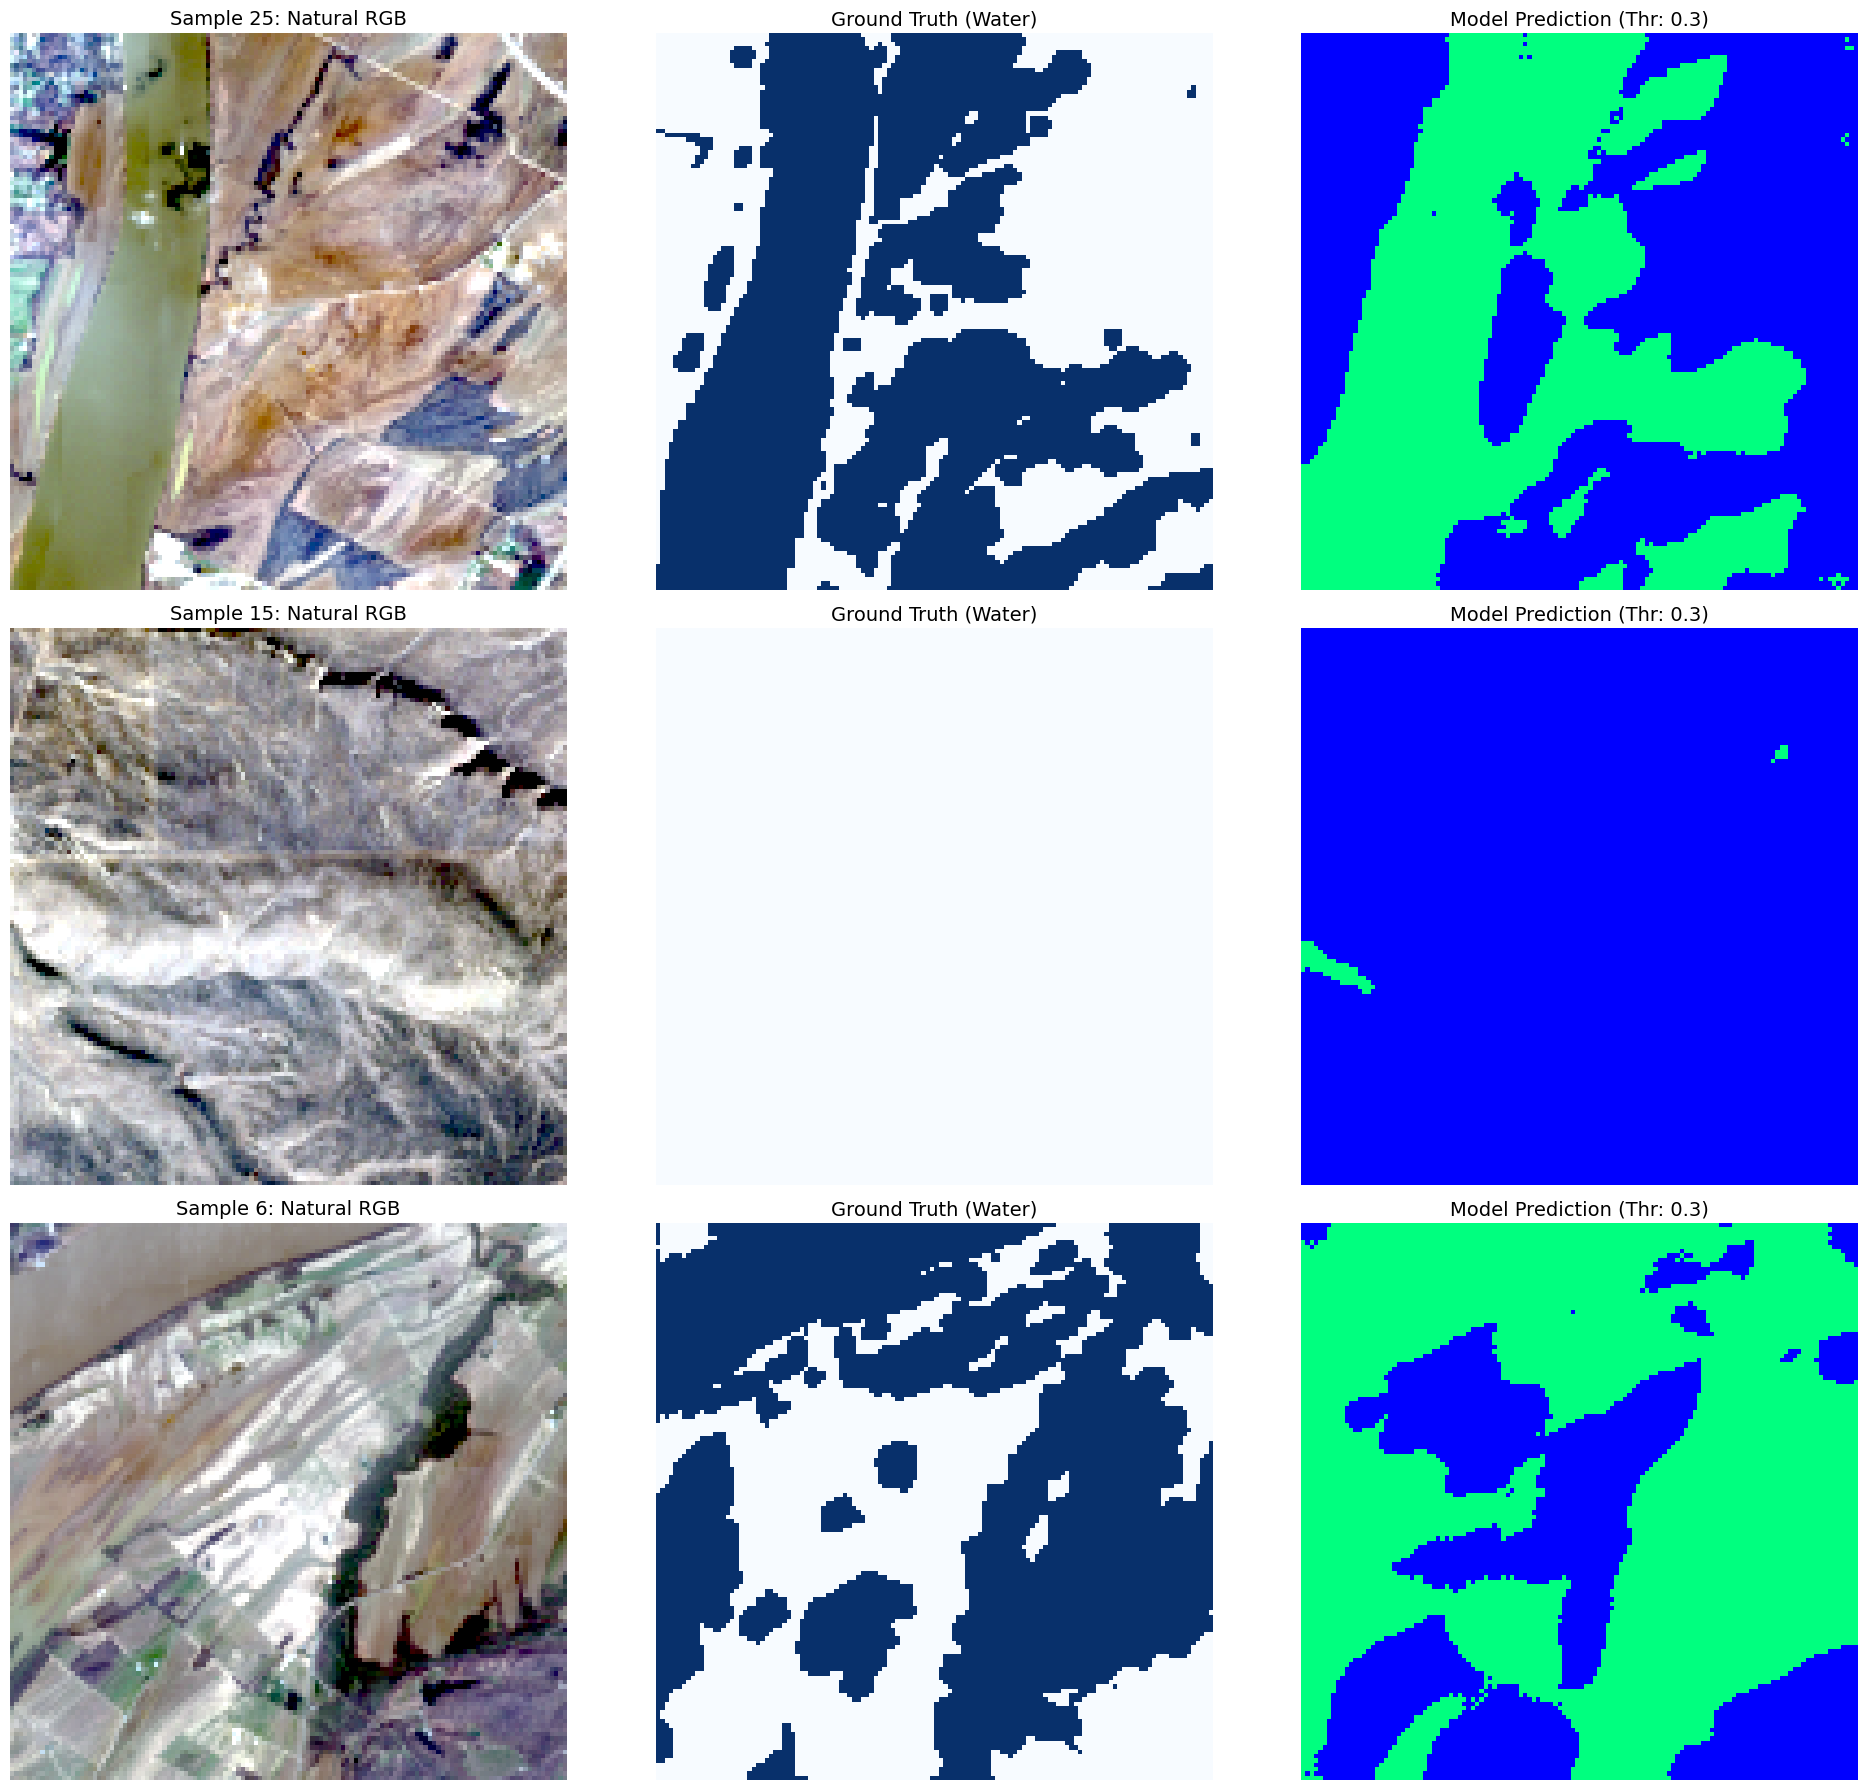

--- Threshold: 0.3 ---


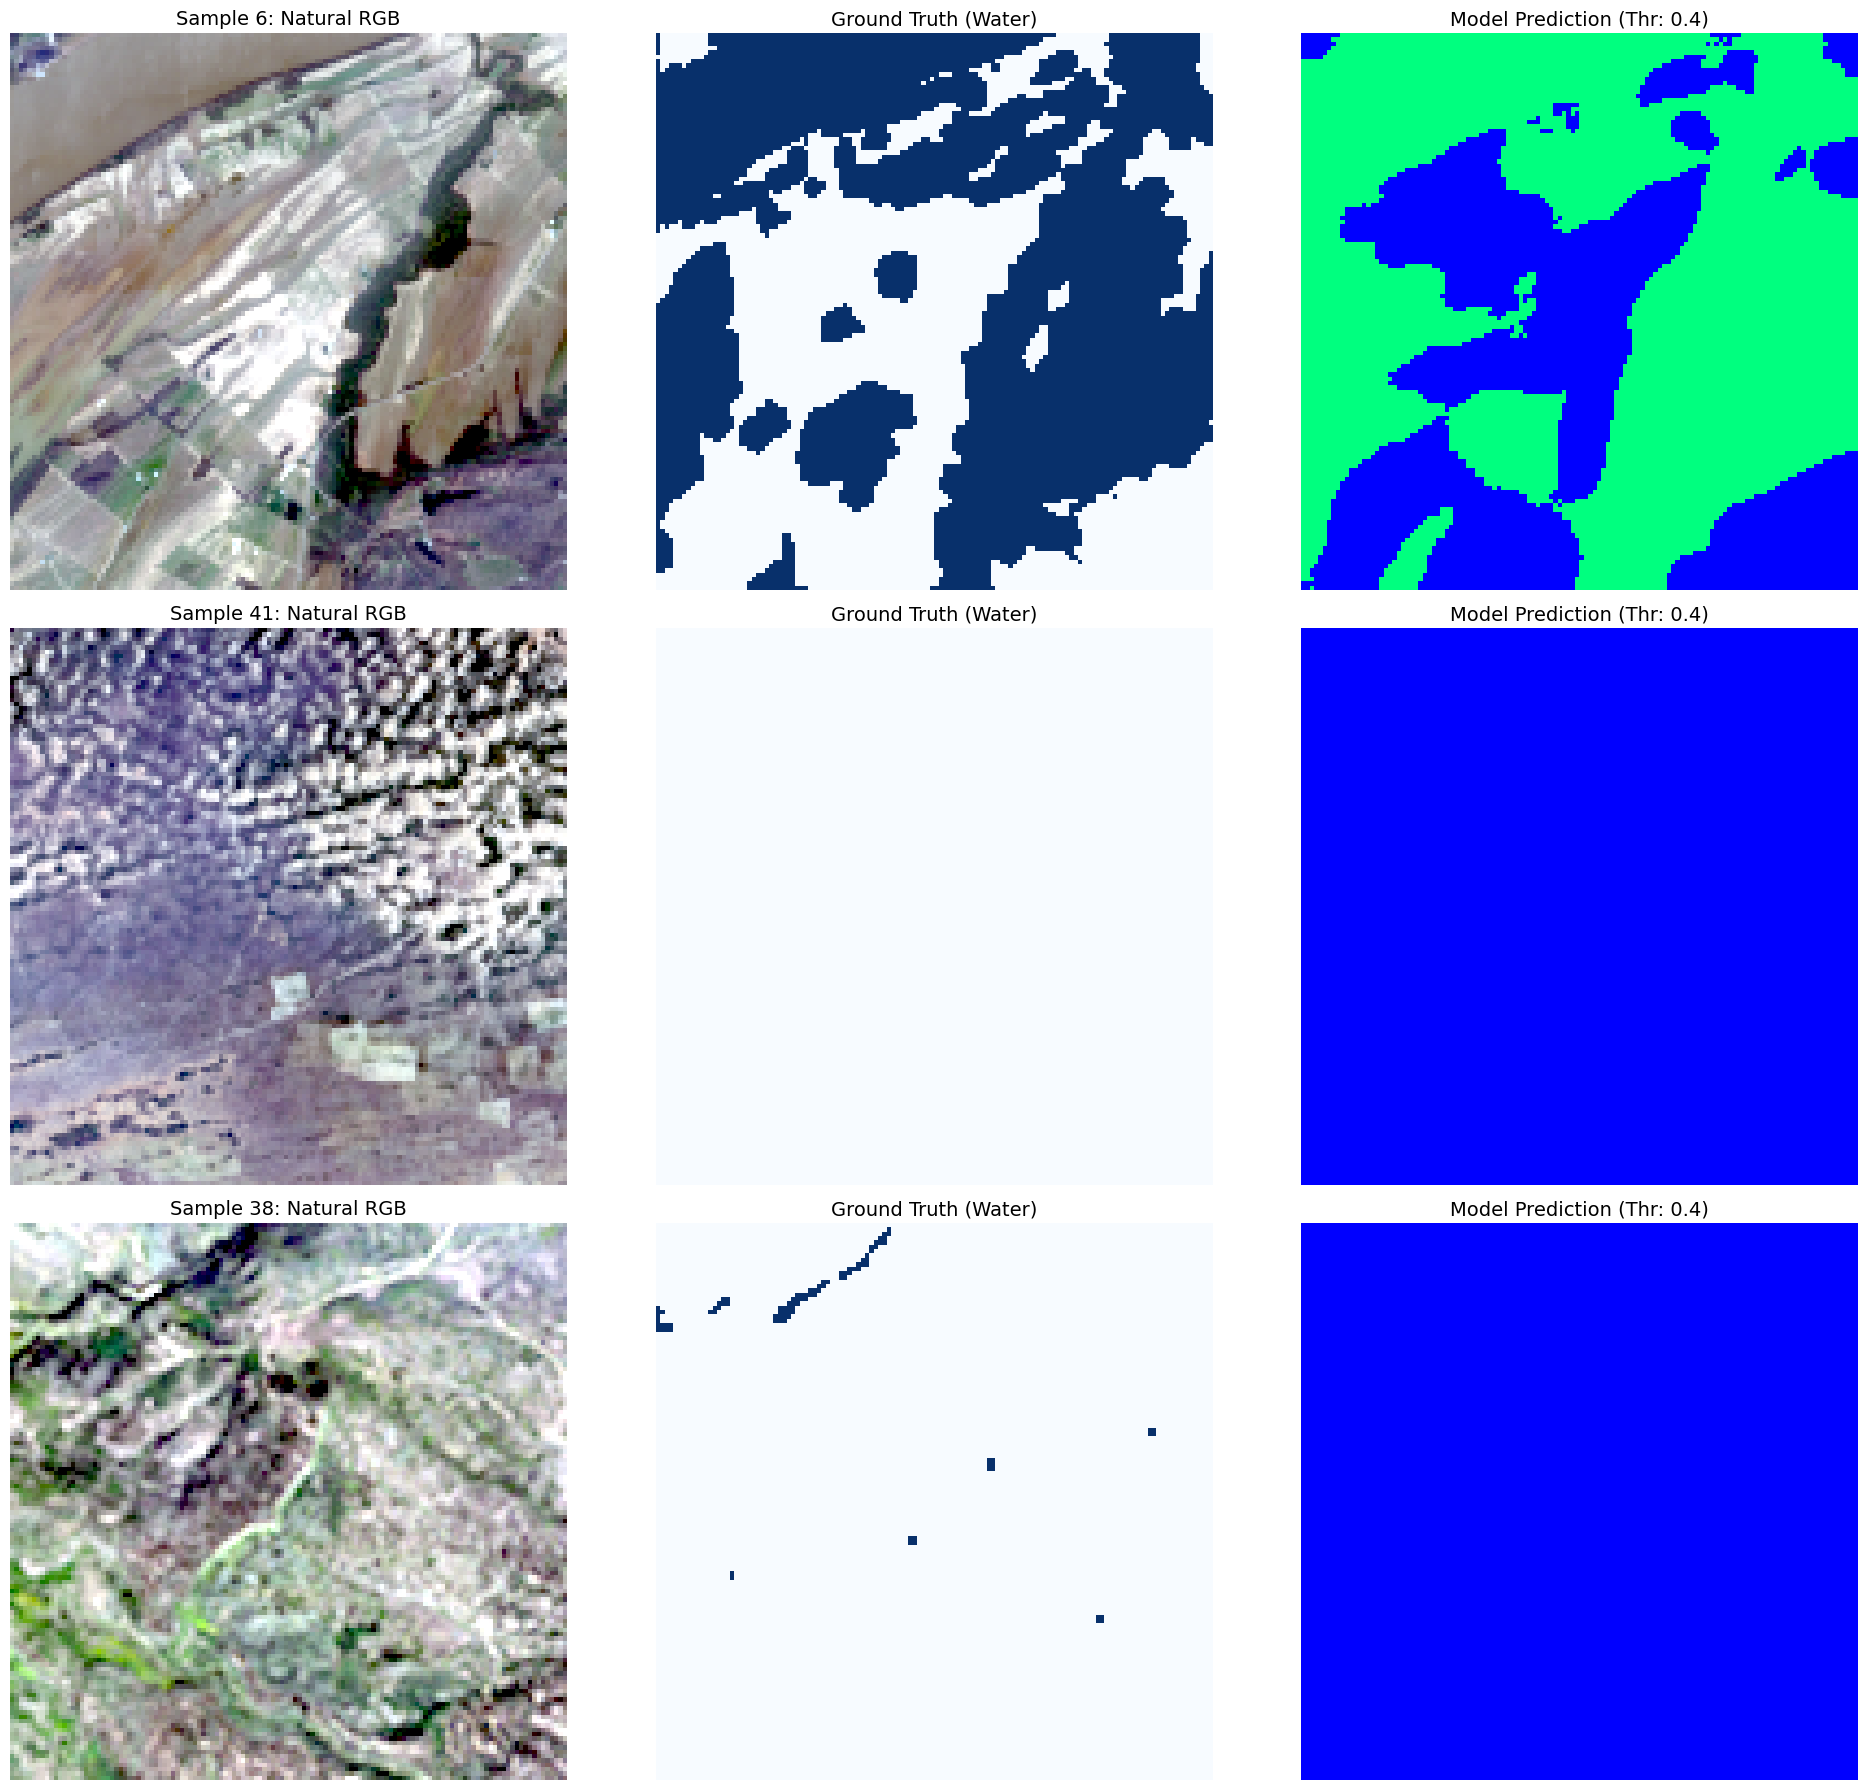

--- Threshold: 0.4 ---


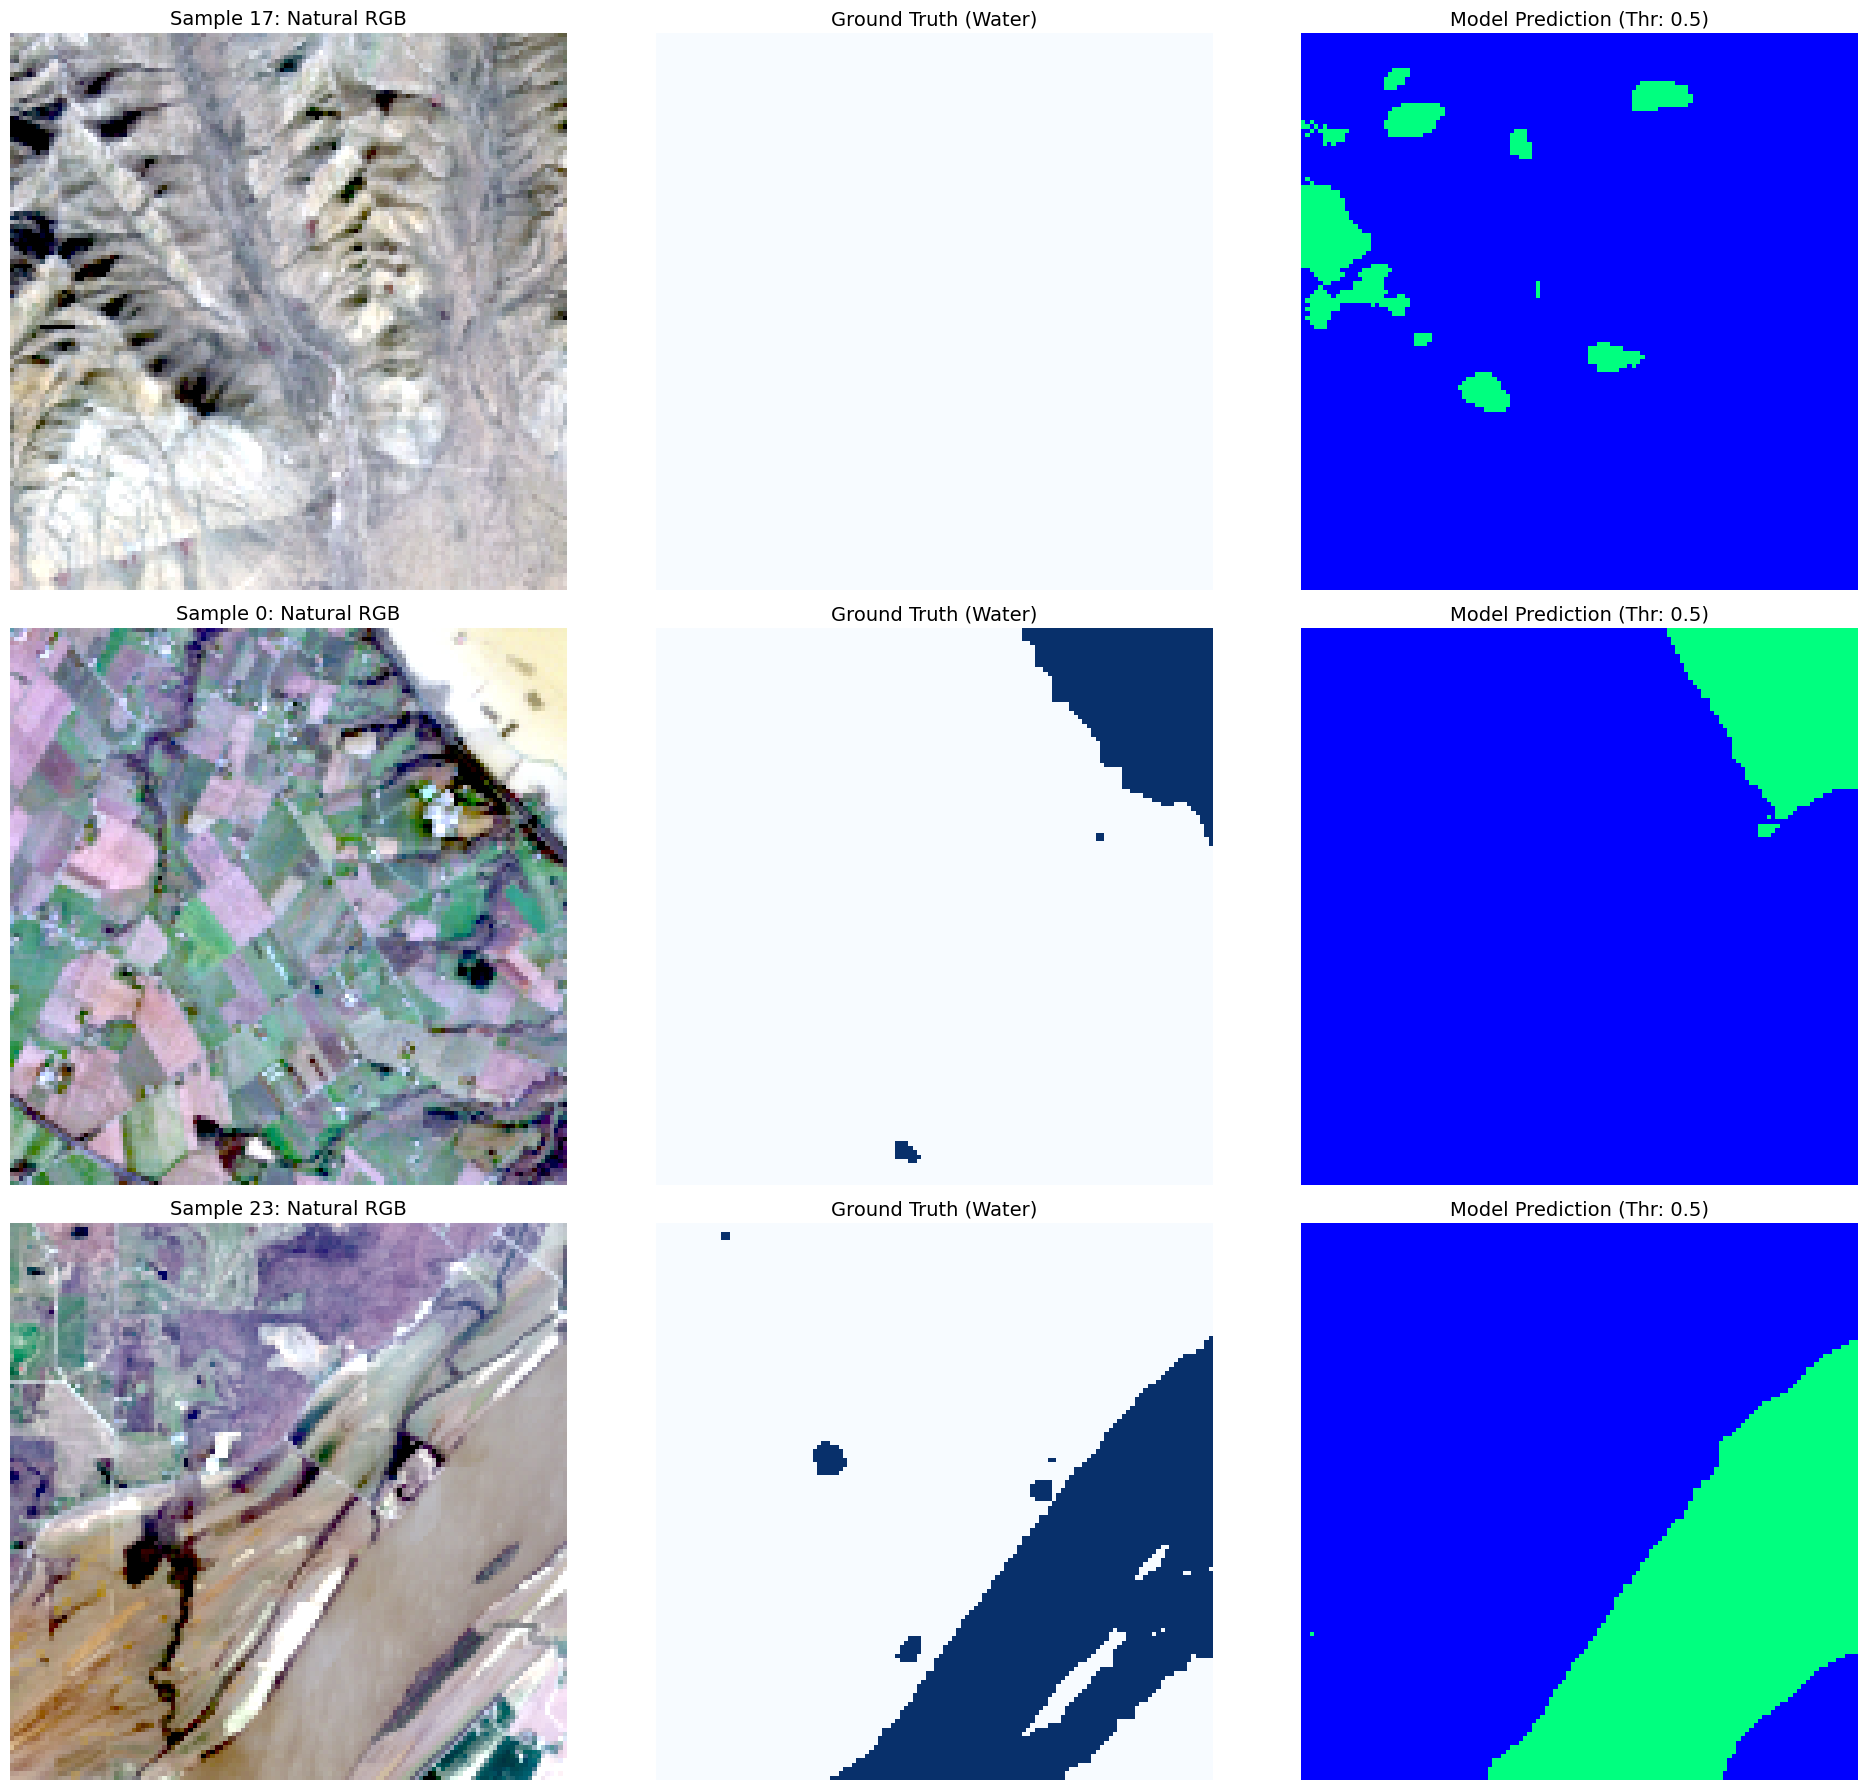

--- Threshold: 0.5 ---


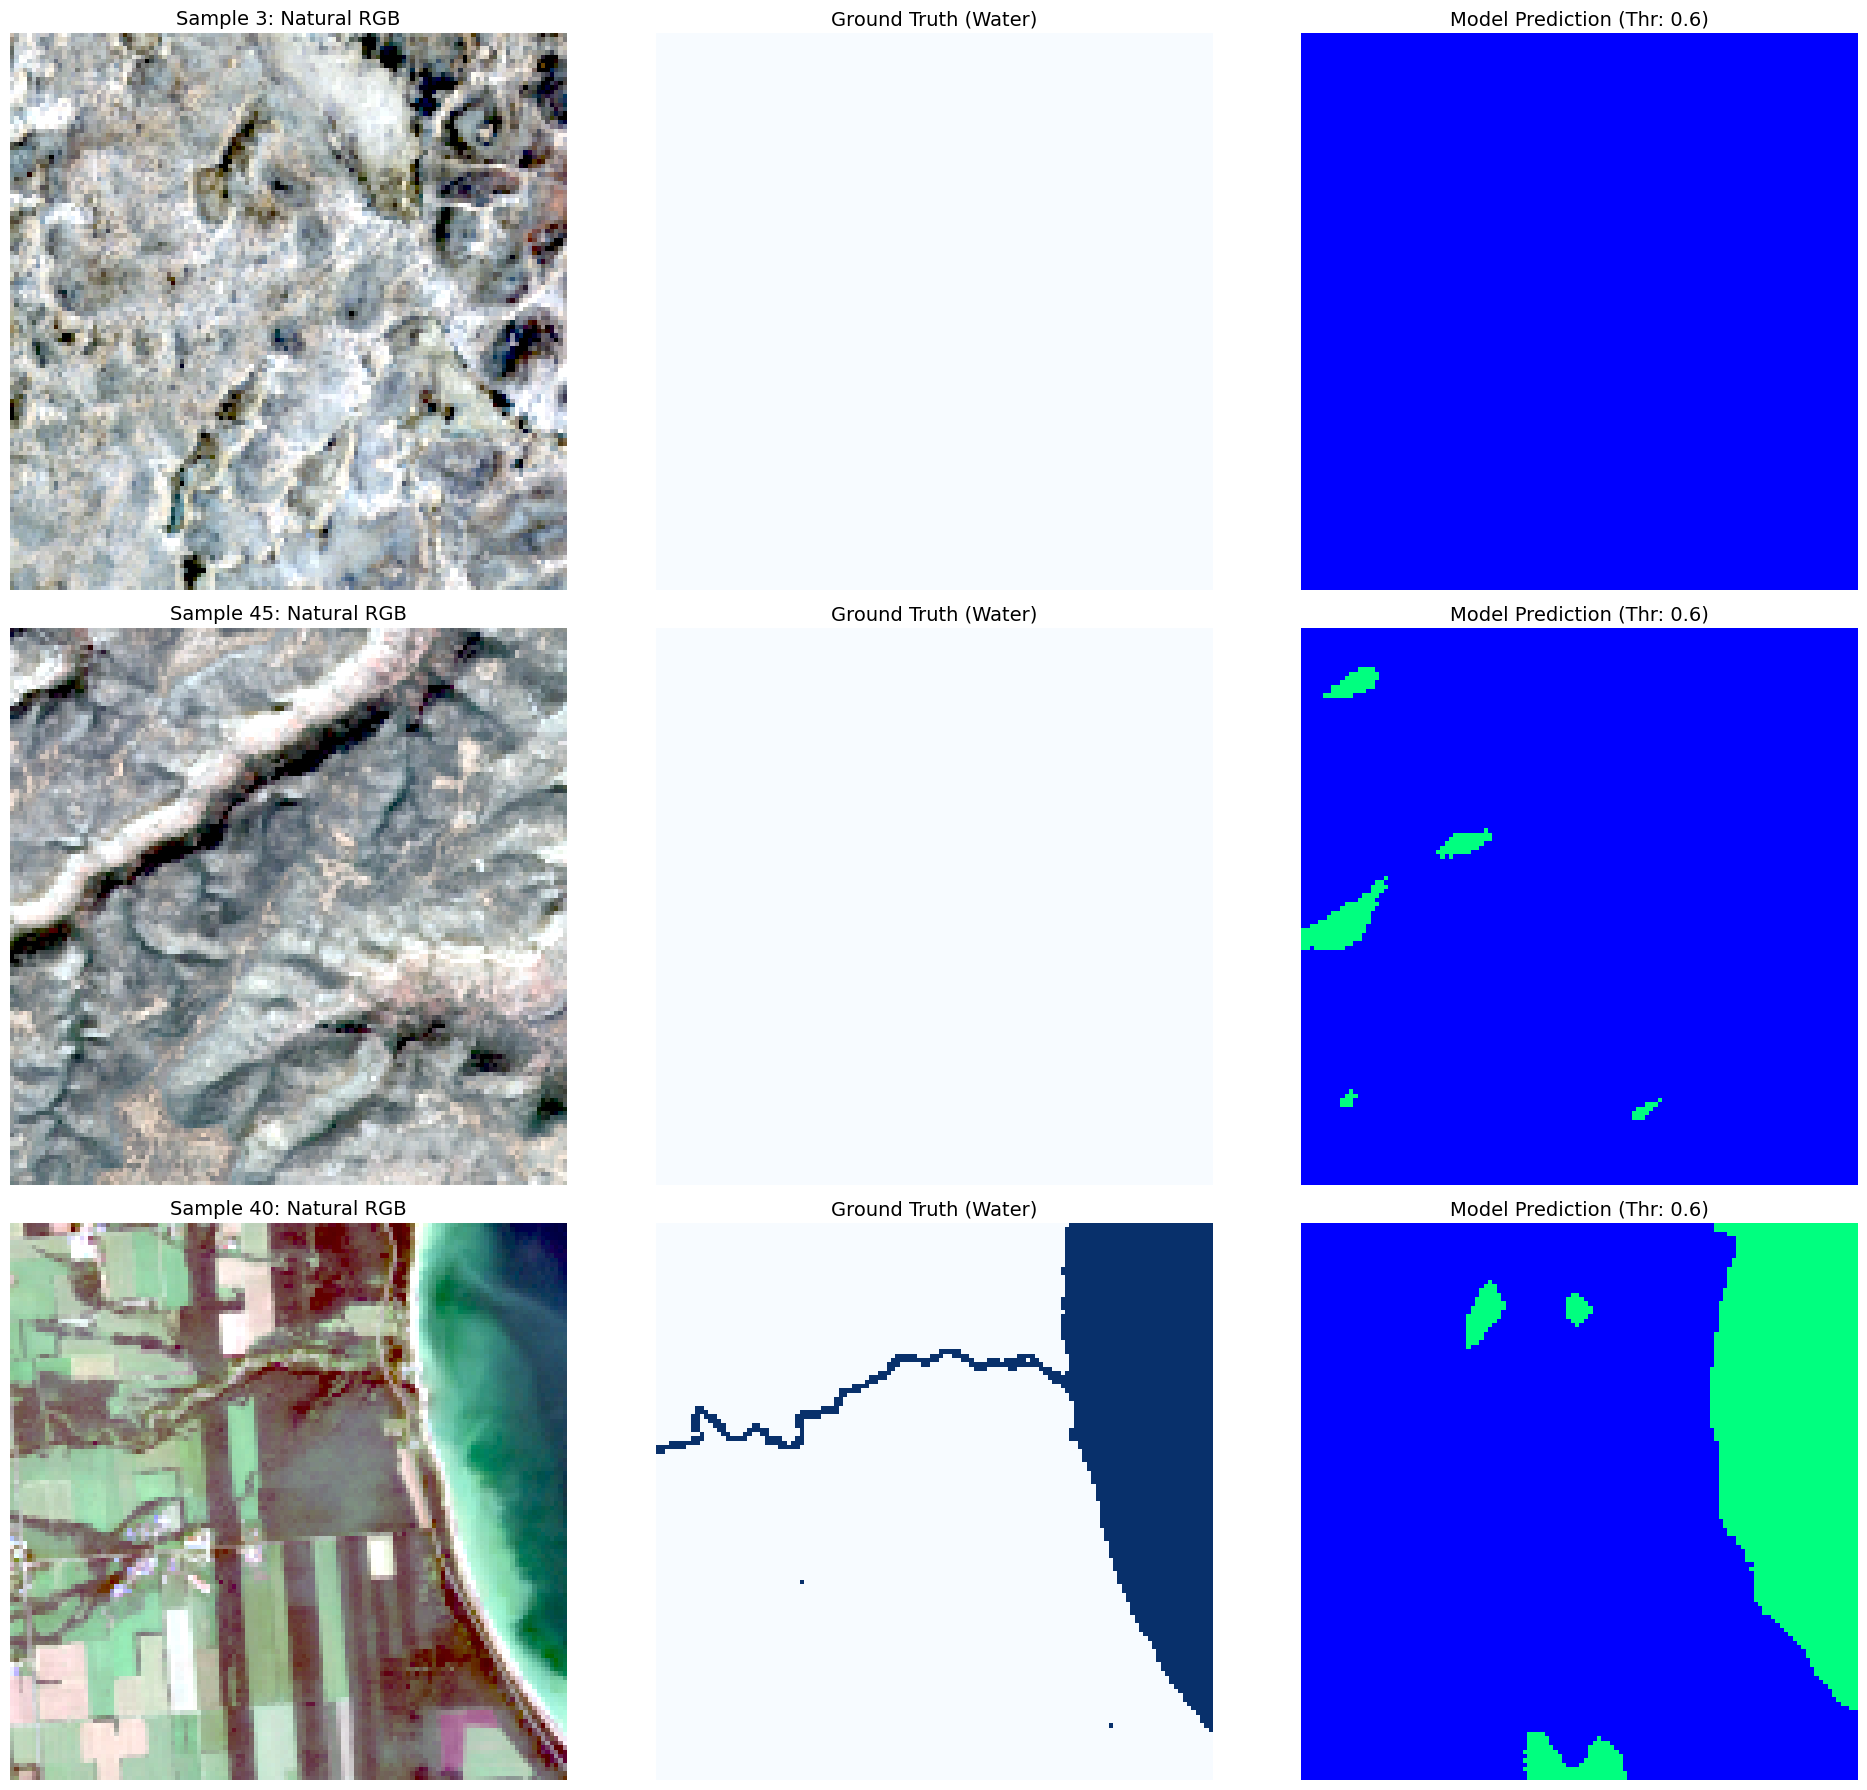

--- Threshold: 0.6 ---


In [20]:
# جربي القيم دي وشوفي الأحسن
for threshold in [0.3, 0.4, 0.5, 0.6]:
    visualize_five_samples(
        model,
        test_data['images'],
        test_data['masks'],
        n=3,
        gamma=0.5,
        threshold=threshold
    )
    print(f"--- Threshold: {threshold} ---")

In [21]:
# Evaluate on test set
test_results = model.evaluate(test_data['images'], test_data['masks'], verbose=1)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Dice: {test_results[2]:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - binary_accuracy: 0.9152 - dice_coef: 0.7209 - loss: 0.5165
Test Loss: 0.5134
Test Accuracy: 0.9155
Test Dice: 0.7237


In [22]:
model.save('vgg16_unet_water_segmentation.h5')
print("Model saved.")

Model saved.


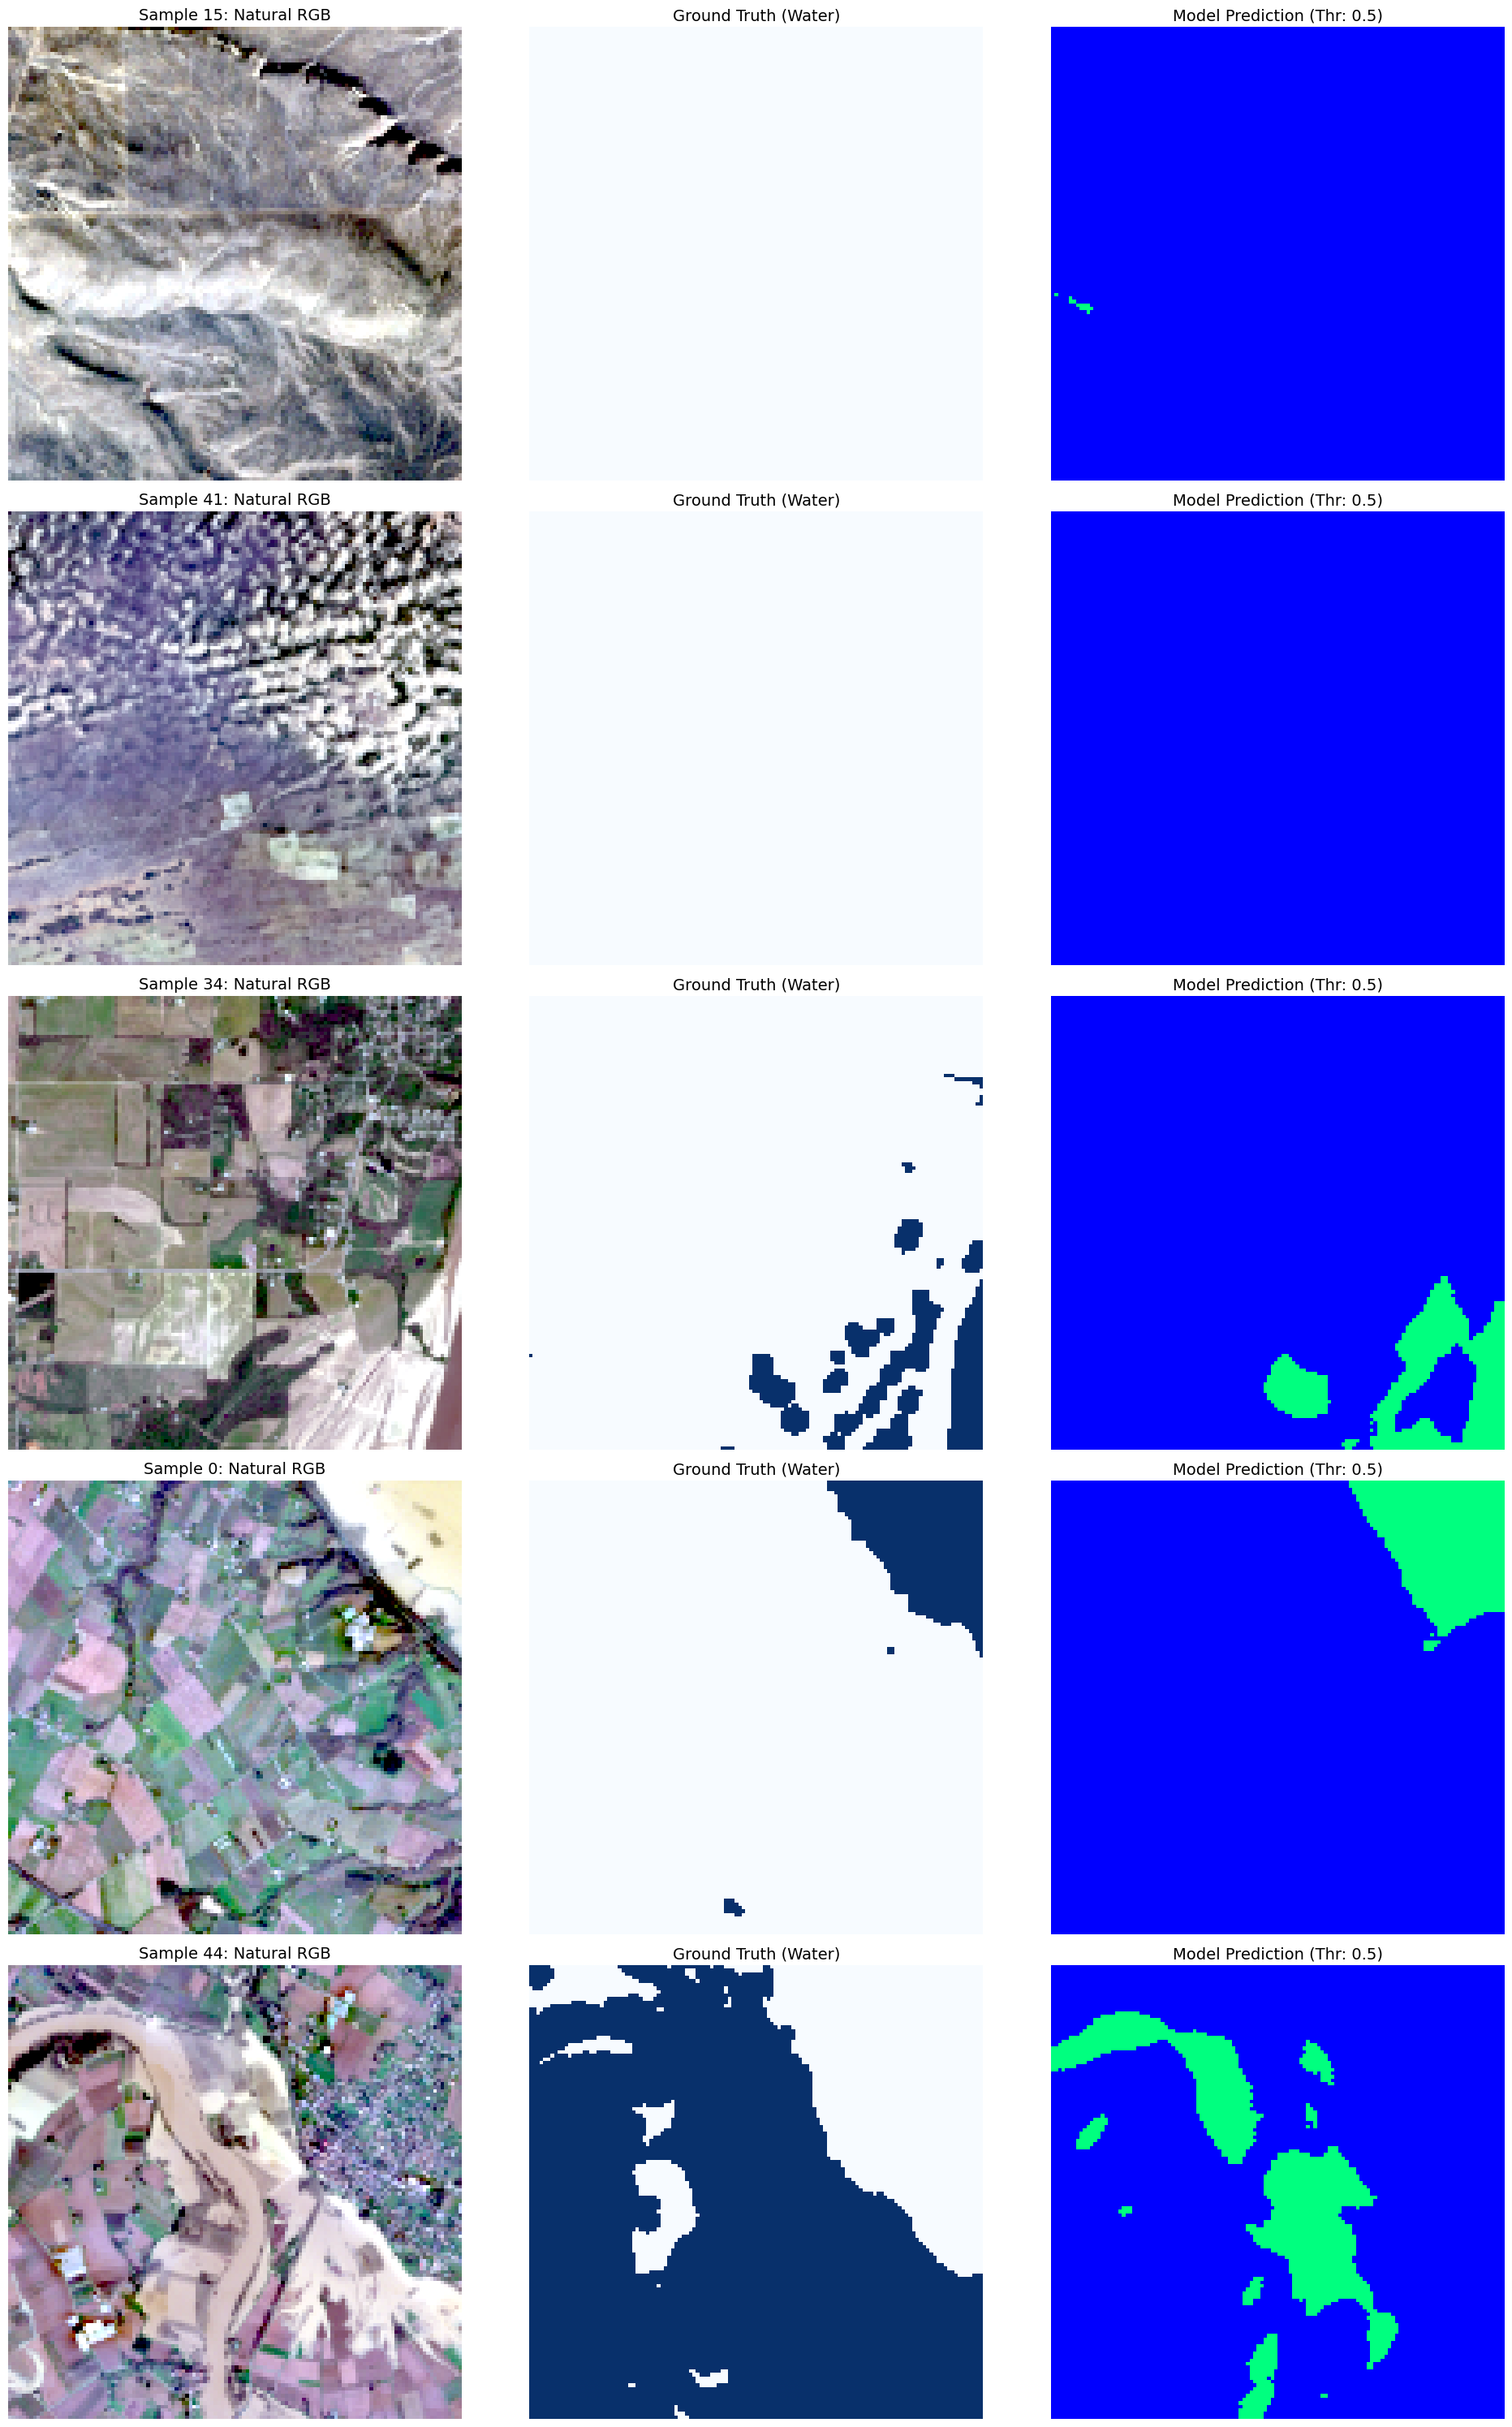

In [23]:
visualize_five_samples(
    model,
    test_data['images'],
    test_data['masks'],
    n=5,
    gamma=0.5,
    threshold=0.5
)